# KNN - K nearest neighbours

In [116]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()

wine.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [117]:
wine["feature_names"]

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [118]:
wine["target_names"]

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [119]:
len(["feature_names"])

1

goal: dataframe with features and target

In [120]:
df = pd.DataFrame(wine["data"], columns=wine["feature_names"])
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [121]:
df_wine_classes = pd.DataFrame(wine["target"], columns=["wine_class"])
df_wine_classes.head()

,wine_class
0,0
1,0
2,0
3,0
4,0


In [122]:
df_with_target = pd.concat([df, df_wine_classes],axis=1)
df_with_target.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [123]:
df["region"] = wine["target"]
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,region
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  regio

In [125]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,region
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [126]:
wine["target"]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [127]:
wine["target_names"]

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [128]:
wine["target"].shape, wine["data"].shape

((178,), (178, 13))

In [129]:
df_with_target.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  wine_

# Correlation heatmap for feature selection / feature engineering

<Axes: >

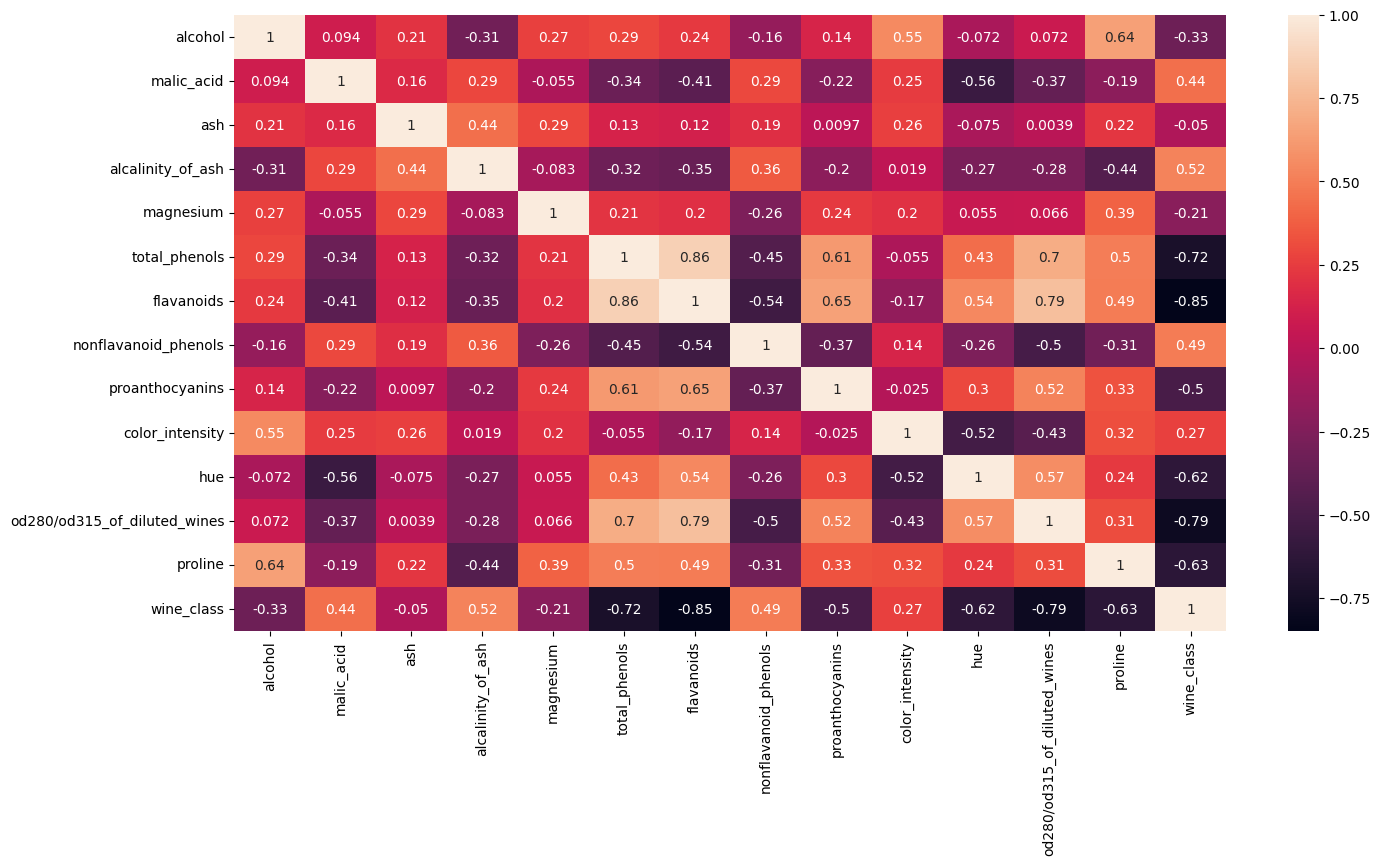

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

fig,ax = plt.subplots(1, figsize=(16, 8))


sns.heatmap(df_with_target.corr(), annot=True)

In [131]:
df_feature_select = df_with_target.drop(["ash", "total_phenols", "magnesium"], axis=1)
df_feature_select

,alcohol,malic_acid,alcalinity_of_ash,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,15.6,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,11.2,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,18.6,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,16.8,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,21.0,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,20.5,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,23.0,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,20.0,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,20.0,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


# KNN

### divide into feature matrix and target vector

In [132]:
X, y = df_feature_select.drop("wine_class", axis=1), df_feature_select["wine_class"]
X.head()

,alcohol,malic_acid,alcalinity_of_ash,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,15.6,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,11.2,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,18.6,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,16.8,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,21.0,2.69,0.39,1.82,4.32,1.04,2.93,735.0


### train|test split

In [133]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)


X_train.shape

(89, 10)

### scale dataset

In [134]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)
scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)

scaled_X_train.min(), scaled_X_train.max(), scaled_X_test.min(), scaled_X_test.max()

(np.float64(0.0),
 np.float64(1.0),
 np.float64(-0.05077262693156731),
 np.float64(1.2428256070640176))

### KNN model

In [135]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=1)
model.fit(scaled_X_train, y_train)

y_pred = model.predict(scaled_X_test)
y_pred

array([0, 0, 2, 0, 1, 0, 1, 2, 1, 2, 0, 2, 0, 2, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 2, 2, 2, 1, 1, 1, 0, 0, 1, 2, 0, 0, 0, 2, 2, 1, 2, 0, 1, 1, 1,
       2, 0, 1, 1, 2, 0, 1, 0, 0, 2, 2, 1, 1, 0, 1, 0, 2, 1, 1, 2, 0, 0,
       0, 2, 0, 0, 1, 2, 1, 0, 2, 0, 0, 2, 1, 1, 0, 1, 0, 0, 1, 1, 0, 2,
       1])

In [136]:
y_test.values

array([0, 0, 2, 0, 1, 0, 1, 2, 1, 2, 0, 2, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 2, 2, 2, 1, 1, 1, 0, 0, 1, 2, 0, 0, 0, 2, 2, 1, 2, 0, 1, 1, 1,
       2, 0, 1, 1, 2, 0, 1, 0, 0, 2, 2, 1, 1, 0, 1, 0, 2, 1, 1, 2, 0, 0,
       0, 2, 0, 0, 1, 2, 1, 0, 2, 1, 0, 2, 1, 1, 0, 1, 0, 0, 1, 0, 0, 2,
       1])

## evaluate model

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        33
           1       0.97      0.94      0.96        34
           2       0.96      1.00      0.98        22

    accuracy                           0.97        89
   macro avg       0.97      0.97      0.97        89
weighted avg       0.97      0.97      0.97        89



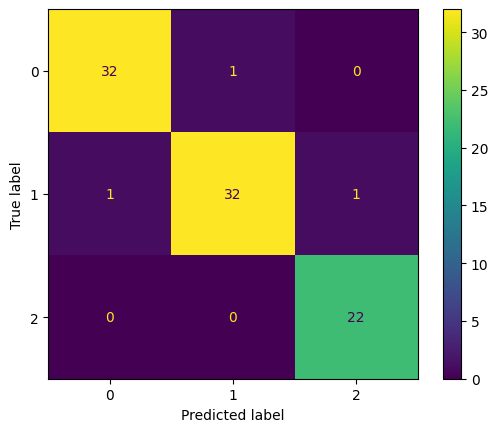

In [137]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print(classification_report(y_test, y_pred))
cm= confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot();




## tune hyperparameter k (n_neighbours) with elbow plot

In [138]:
from sklearn.metrics import accuracy_score

error = 1-accuracy_score(y_test, y_pred)
error

0.0337078651685393

In [140]:
error_list =[]
for k in range(1, 50):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(scaled_X_train, y_train)
    y_pred = model.predict(scaled_X_test)
    error = 1 - accuracy_score(y_test, y_pred)
    error_list.append(error)

error_list

[0.0337078651685393,
 0.0674157303370787,
 0.0337078651685393,
 0.0449438202247191,
 0.0449438202247191,
 0.0449438202247191,
 0.0337078651685393,
 0.0449438202247191,
 0.0337078651685393,
 0.022471910112359605,
 0.022471910112359605,
 0.022471910112359605,
 0.022471910112359605,
 0.022471910112359605,
 0.022471910112359605,
 0.0337078651685393,
 0.022471910112359605,
 0.0337078651685393,
 0.022471910112359605,
 0.0337078651685393,
 0.0337078651685393,
 0.0337078651685393,
 0.0337078651685393,
 0.0337078651685393,
 0.0337078651685393,
 0.0337078651685393,
 0.0337078651685393,
 0.0337078651685393,
 0.0449438202247191,
 0.0449438202247191,
 0.0449438202247191,
 0.0449438202247191,
 0.0449438202247191,
 0.0449438202247191,
 0.0449438202247191,
 0.0449438202247191,
 0.0449438202247191,
 0.0449438202247191,
 0.0449438202247191,
 0.0449438202247191,
 0.0449438202247191,
 0.0337078651685393,
 0.0337078651685393,
 0.0337078651685393,
 0.0337078651685393,
 0.0337078651685393,
 0.033707865168539

# Gör en elbow plot nedan samt fråga copilot om det:

[Text(0.5, 0, 'k neighbours'),
 Text(0, 0.5, 'Error'),
 Text(0.5, 1.0, 'Elbow plot to choose k')]

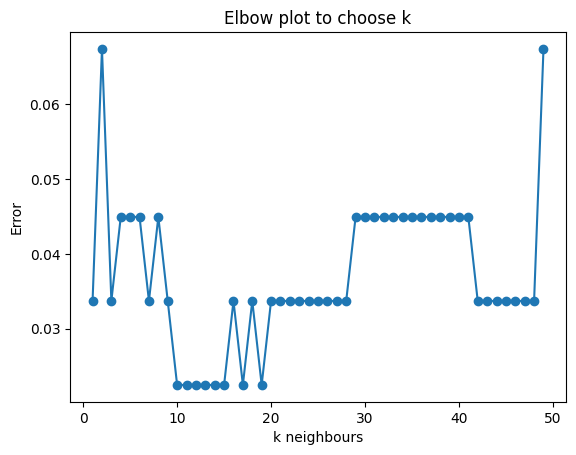

In [148]:
fig, ax = plt.subplots(1)

ax.plot(range(1,50), error_list, '-o')
ax.set(xlabel= "k neighbours", ylabel= "Error", title= "Elbow plot to choose k")

Here choose "k" = 10 or 11 and train on all data (train and test part), save/export model

BUT, to be more robust, follow these steps to prevent data leakage:

- do train|val|test split (use train|test split twice)
- calculate error based on validation data
- choose k on elbow plot with validation data
- train on tran + validation data
- evaluate on test data
- train on all data
- export model
